# Import setting

In [1]:

%load_ext autoreload
%autoreload 2

from src.config import Configuration

CONFIG = Configuration(
    num_classes=20,
    image_size=224
)

________________________________________________________________________________________________________________________________
                                                         CONFIGURATION                                                          

Experiment description: Base experiment description
Experiment name: base_name
Model type: small
seed: 42
batch_size: 128
epochs: 100
dropout_rate: 0.5
label_smoothing: 0.1
learning_rate: 0.01
weight_decay: 0.0001
eta_min: 1e-06
momentum: 0.9
lr_reduce_factor: 0.5
lr_patience: 3
patience: 10



# Load data

In [2]:
from src.data import load_car_data

train_loader, test_loader = load_car_data(CONFIG, use_transforms=False)

In [3]:
import numpy as np

x_train = np.load(CONFIG.car_x_train)
x_test = np.load(CONFIG.car_x_test)

y_train = np.load(CONFIG.car_y_train)
y_test = np.load(CONFIG.car_y_test)

y_train -= 1
y_test -= 1


### See data

(791, 250, 250, 3)
(791,)
20
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
0.0405
(784, 250, 250, 3)
(784,)
32
26
0.0408


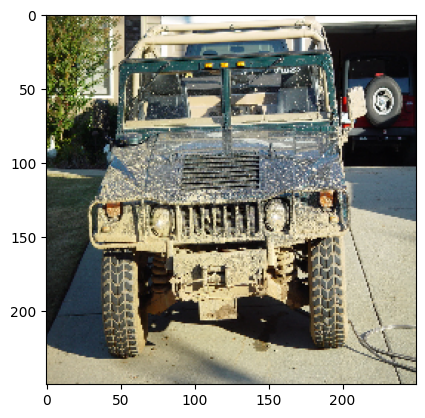

(791, 250, 250, 3)
(784, 250, 250, 3)


In [4]:
import matplotlib.pyplot as plt
print(x_train.shape)
print(y_train.shape)
print(len(np.unique(y_train)))
print(np.unique(y_train))
print("{:.4f}".format(sum(y_train == 1)/y_train.shape[0]))
print(x_test.shape)
print(y_test.shape)
print(sum(y_test == 1))
print(sum(y_test == 0))
print("{:.4f}".format(sum(y_test == 1)/y_test.shape[0]))


## View some images
plt.imshow(x_train[0,:,:,: ] )
plt.show()


## Transforms
# x_train = x_train.astype('float32')
# x_test = x_test.astype('float32')

# y_train = y_train.astype('float32')
# y_test = y_test.astype('float32')


# x_train /= 255
# x_test /= 255

print(x_train.shape)
print(x_test.shape)

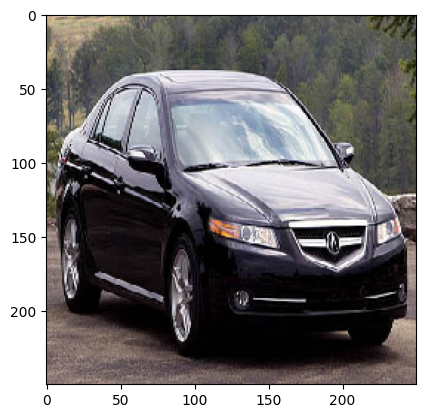

In [5]:
plt.imshow(x_train[np.random.randint(0, x_train.shape[0]),:,:,: ] )
plt.show()

# Models

### Trained models

In [6]:
import torch.nn as nn
import torchvision.models as models

# Instantiate models and extract only the convolutional feature layers
model1 = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features

resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model2 = nn.Sequential(*list(resnet.children())[:-2])

### Bilinear trained model

In [7]:
import os
import re
from src.models import CarModule

model_name = "stage2-vg-res-epoch=29-val_acc=0.7372.ckpt"
best_model_path = os.path.join(CONFIG.car_models, model_name)
print(f"\nLoading: {model_name}")
CONFIG.model_type = re.search(r"stage2-([\w-]+)-epoch", model_name).group(1)

# Load with strict=False to handle classifier size differences
model = CarModule.load_from_checkpoint(best_model_path, CONFIG=CONFIG)
model.eval()
model.to(CONFIG.device)


Loading: stage2-vg-res-epoch=29-val_acc=0.7372.ckpt


CarModule(
  (model): BilinearCarCNN(
    (model1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
 

In [8]:
import torch

# Make predictions on all test data using the same pipeline as training
all_predictions = []
all_true_labels = []

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(CONFIG.device)
        y_batch = y_batch.to(CONFIG.device)

        logits = model(x_batch)
        preds = torch.argmax(logits, dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_true_labels.extend(y_batch.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

# Calculate overall accuracy
accuracy = (all_predictions == all_true_labels).mean()
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Total test samples: {len(all_true_labels)}")
print(f"Correct predictions: {(all_predictions == all_true_labels).sum()}")
print(f"Incorrect predictions: {(all_predictions != all_true_labels).sum()}")

Test Accuracy: 0.7372
Total test samples: 784
Correct predictions: 578
Incorrect predictions: 206


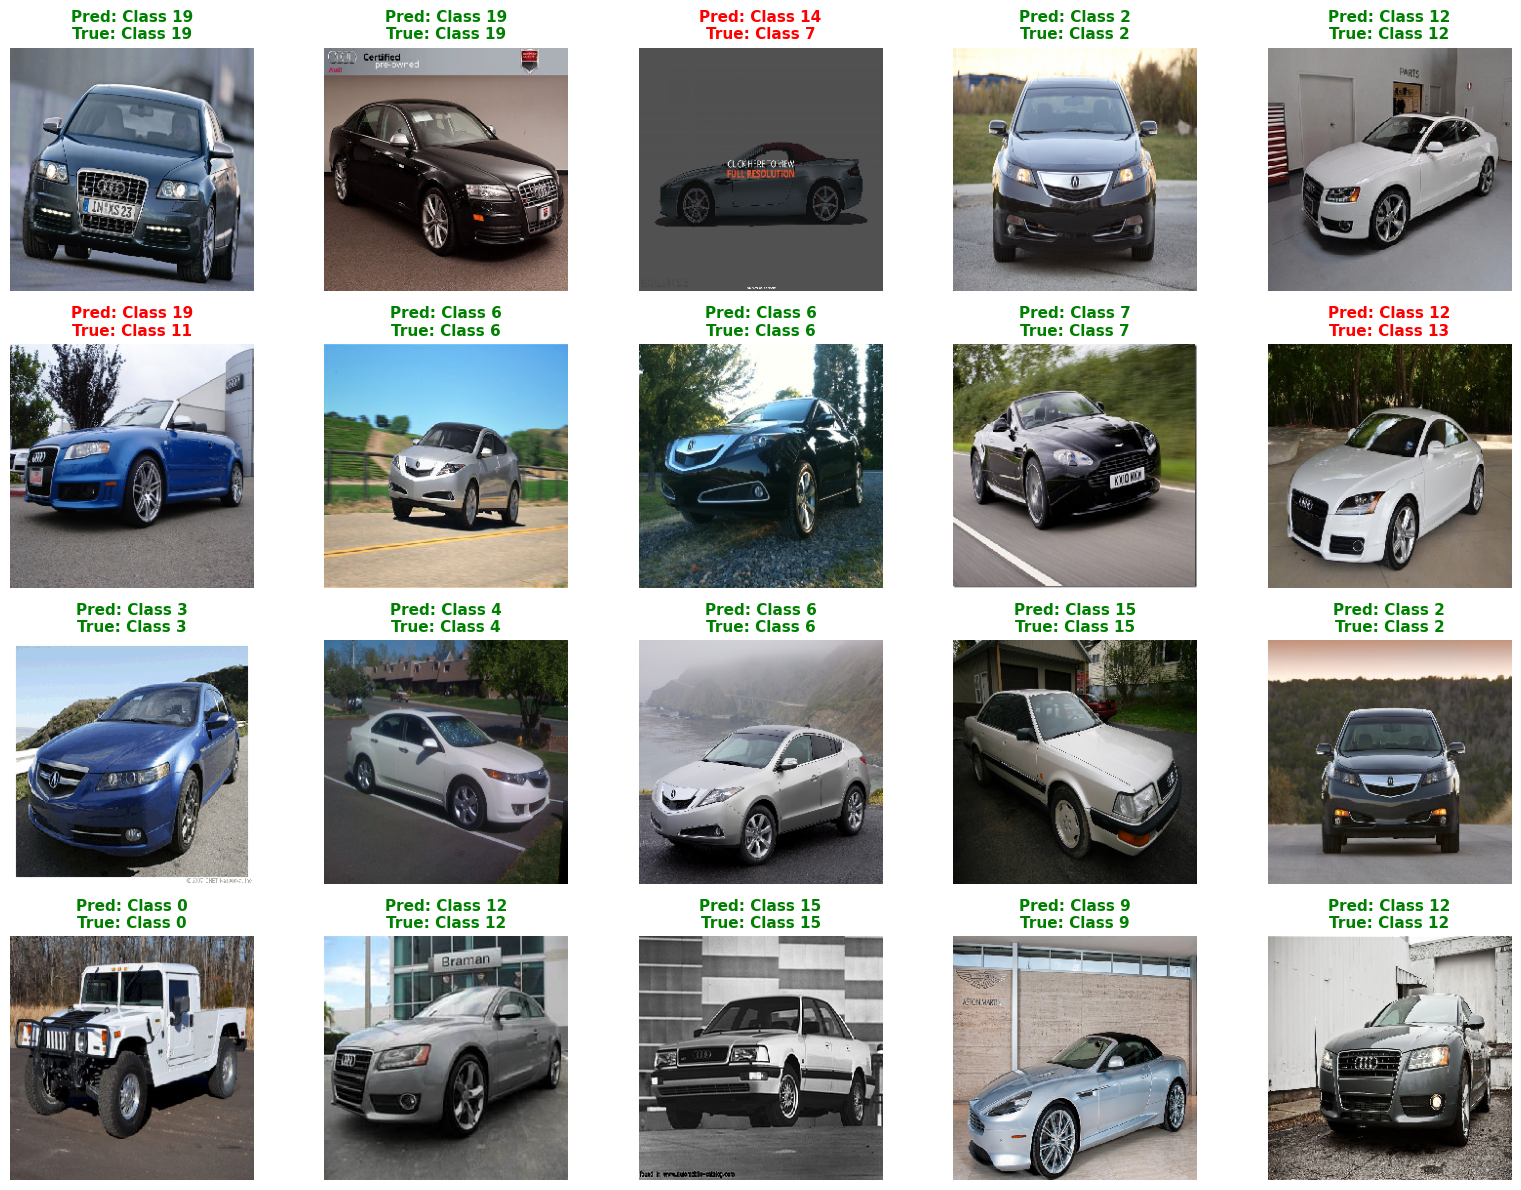

In [10]:
# Display 4x5 grid (20 images) with predictions and true values
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.flatten()

# Randomly select 20 test images
# np.random.seed(42)
indices = np.random.choice(len(x_test), 20, replace=False)

# Create class names for all 20 classes
class_names = {i: f"Class {i}" for i in range(20)}

for idx, ax_idx in enumerate(indices):
    ax = axes[idx]
    
    # Display image
    ax.imshow(x_test[ax_idx].astype('uint8'))
    
    # Get prediction and true label
    pred = int(all_predictions[ax_idx])
    true = int(y_test[ax_idx])
    
    # Color: green if correct, red if incorrect
    color = "green" if pred == true else "red"
    
    # Title with prediction and true label
    title = f"Pred: {class_names[pred]}\nTrue: {class_names[true]}"
    ax.set_title(title, fontsize=11, fontweight="bold", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()